# Alcaldía-Level Comparison: Demographics, Economy & Public Safety

**Author:** Gustavo Fuentes (`Audileleach`) · Phase 3 · TEAM_PLAN §4.6
**Study Area:** the 16 alcaldías of Mexico City (all 2,431 urban AGEBs)
**Method:** territorial aggregation — sum numerators and denominators over the AGEBs of each alcaldía, then divide

This notebook compares the 16 alcaldías on population, population and business density, businesses per 1,000 residents, dominant sector, crime rate and crimes per 100 businesses, and contrasts the central alcaldías (Cuauhtémoc, Benito Juárez, Miguel Hidalgo) with the rest of the city.

> **Aggregation rule:** an alcaldía ratio is Σ numerator / Σ denominator over its AGEBs. Averaging AGEB ratios would give a 50-resident AGEB the same weight as a 15,000-resident one. All figures cover the urban AGEBs only (99.2 % of CDMX residents).

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.data import load_kpis, load_view
from src.config import OUTPUT_FIGURES
from src.db import get_engine

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
CENTRE = ['Cuauhtémoc', 'Benito Juárez', 'Miguel Hidalgo']

## 1. Load All Urban AGEBs & Aggregate by Alcaldía

KPIs come from `dw.v_kpi_ageb` via `load_kpis()` (all 2,431 AGEBs, low-population ones included because they belong to the alcaldía totals) and alcaldía names from `dw.dim_geography`.

In [2]:
mun_names = pd.read_sql("SELECT cvegeo, mun_name FROM dw.dim_geography", get_engine()).set_index('cvegeo')['mun_name']

kpis = load_kpis(city_core_only=False, exclude_low_population=False)
kpis['alcaldia'] = kpis['cvegeo'].map(mun_names)
assert len(kpis) == 2431, f"Expected 2,431 urban AGEBs, got {len(kpis)}"
assert kpis['alcaldia'].notna().all() and kpis['alcaldia'].nunique() == 16
assert kpis['pop_total'].sum() == 9_138_524

SUMS = ['pop_total', 'area_km2', 'businesses_total', 'retail_total', 'services_total', 'crime_total']

def add_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """KPI ratios from summed numerators and denominators."""
    out = df.copy()
    out['pop_density_km2'] = out['pop_total'] / out['area_km2']
    out['business_density_km2'] = out['businesses_total'] / out['area_km2']
    out['retail_density_km2'] = out['retail_total'] / out['area_km2']
    out['service_density_km2'] = out['services_total'] / out['area_km2']
    out['businesses_per_1k'] = 1000 * out['businesses_total'] / out['pop_total'].where(out['pop_total'] > 0)
    out['services_share_pct'] = 100 * out['services_total'] / out['businesses_total'].where(out['businesses_total'] > 0)
    out['crime_rate_per_1k'] = 1000 * out['crime_total'] / out['pop_total'].where(out['pop_total'] > 0)
    out['crimes_per_100_businesses'] = 100 * out['crime_total'] / out['businesses_total'].where(out['businesses_total'] > 0)
    return out

alcaldia_df = add_ratios(kpis.groupby('alcaldia')[SUMS].sum())
alcaldia_df.insert(0, 'ageb_count', kpis.groupby('alcaldia').size())
assert len(alcaldia_df) == 16

### Dominant sector per alcaldía

From `dw.v_business_by_sector` (establishments per AGEB × SCIAN sector): sum the establishments of each sector over the alcaldía and keep the largest, ties broken alphabetically as in `dw.v_kpi_ageb`.

In [3]:
by_sector = load_view('v_business_by_sector')
by_sector['alcaldia'] = by_sector['cvegeo'].map(mun_names)
sector_totals = (
    by_sector.groupby(['alcaldia', 'sector_name'], as_index=False)['establishments'].sum()
    .sort_values(['alcaldia', 'establishments', 'sector_name'], ascending=[True, False, True])
)
dominant = sector_totals.groupby('alcaldia').head(1).set_index('alcaldia')
alcaldia_df['dominant_sector'] = dominant['sector_name']
alcaldia_df['dominant_sector_share_pct'] = 100 * dominant['establishments'] / alcaldia_df['businesses_total']
assert (dominant['establishments'].groupby(level=0).sum() <= alcaldia_df['businesses_total']).all()

## 2. Ranking Table

Rank 1 = highest value. Sorted by recorded crime rate.

In [4]:
RANKED = {
    'pop_total': 'Population',
    'pop_density_km2': 'Pop. density',
    'business_density_km2': 'Business density',
    'businesses_per_1k': 'Businesses / 1k',
    'crime_rate_per_1k': 'Crime rate / 1k',
    'crimes_per_100_businesses': 'Crimes / 100 businesses',
}
ranks = alcaldia_df[list(RANKED)].rank(ascending=False, method='min').astype(int).add_prefix('rank_')

summary = alcaldia_df.join(ranks).sort_values('crime_rate_per_1k', ascending=False)
summary.index.name = 'alcaldia'
display_cols = [
    'ageb_count', 'pop_total', 'pop_density_km2', 'business_density_km2', 'businesses_per_1k',
    'services_share_pct', 'dominant_sector', 'dominant_sector_share_pct',
    'crime_total', 'crime_rate_per_1k', 'crimes_per_100_businesses',
] + list(ranks.columns)
display(summary[display_cols].round(1))

csv_path = OUTPUT_FIGURES / "35_alcaldia_summary.csv"
summary.round(4).to_csv(csv_path)
print(f"Saved alcaldía summary table to {csv_path.relative_to(ROOT)}")

,ageb_count,pop_total,pop_density_km2,business_density_km2,businesses_per_1k,services_share_pct,dominant_sector,dominant_sector_share_pct,crime_total,crime_rate_per_1k,crimes_per_100_businesses,rank_pop_total,rank_pop_density_km2,rank_business_density_km2,rank_businesses_per_1k,rank_crime_rate_per_1k,rank_crimes_per_100_businesses
alcaldia,,,,,,,,,,,,,,,,,
Cuauhtémoc,153,545884,16881.9,2088.7,123.7,37.0,Retail trade,50.8,16082,29.5,23.8,6,2,1,1,1,9
Benito Juárez,102,434153,16352.9,911.7,55.7,58.3,Retail trade,28.7,8627,19.9,35.6,8,3,3,5,2,1
Miguel Hidalgo,130,414470,8980.0,548.7,61.1,52.8,Retail trade,32.4,6795,16.4,26.8,11,12,8,3,3,8
Venustiano Carranza,151,443704,13179.7,912.8,69.3,34.4,Retail trade,54.9,6724,15.2,21.9,7,7,2,2,4,12
Iztacalco,110,404695,17623.9,758.0,43.0,42.5,Retail trade,43.7,5382,13.3,30.9,12,1,5,11,5,3
Coyoacán,156,614447,11458.8,466.4,40.7,49.9,Retail trade,39.6,8137,13.2,32.5,5,9,9,13,6,2
Azcapotzalco,103,432205,12970.1,564.6,43.5,43.6,Retail trade,41.0,5074,11.7,27.0,9,8,7,9,7,7
Tlalpan,207,681501,7310.3,279.3,38.2,45.3,Retail trade,43.7,7651,11.2,29.4,4,13,14,14,8,5
La Magdalena Contreras,52,246428,13583.1,465.7,34.3,43.4,Retail trade,46.7,2460,10.0,29.1,14,5,10,15,9,6


Saved alcaldía summary table to outputs\figures\35_alcaldia_summary.csv


## 3. Centre vs Rest of the City

**Centre:** Cuauhtémoc, Benito Juárez and Miguel Hidalgo (TEAM_PLAN §4.6). **Rest of the city:** the other 13 alcaldías. Each group's ratios are again computed from sums.

In [5]:
kpis['zone'] = kpis['alcaldia'].isin(CENTRE).map({True: 'Centre (3 alcaldías)', False: 'Rest of the city (13 alcaldías)'})
zones = add_ratios(kpis.groupby('zone')[SUMS].sum())
zones.loc['Mexico City (urban AGEBs)'] = add_ratios(kpis[SUMS].sum().to_frame().T).iloc[0]
zones['share_of_population_pct'] = 100 * zones['pop_total'] / kpis['pop_total'].sum()
zones['share_of_businesses_pct'] = 100 * zones['businesses_total'] / kpis['businesses_total'].sum()
zones['share_of_crime_pct'] = 100 * zones['crime_total'] / kpis['crime_total'].sum()
display(zones[[
    'pop_total', 'share_of_population_pct', 'businesses_total', 'share_of_businesses_pct',
    'crime_total', 'share_of_crime_pct', 'pop_density_km2', 'business_density_km2',
    'businesses_per_1k', 'crime_rate_per_1k', 'crimes_per_100_businesses',
]].T.round(1))

zone,Centre (3 alcaldías),Rest of the city (13 alcaldías),Mexico City (urban AGEBs)
pop_total,1394507.0,7744017.0,9138524.0
share_of_population_pct,15.3,84.7,100.0
businesses_total,117066.0,344165.0,461231.0
share_of_businesses_pct,25.4,74.6,100.0
crime_total,31504.0,80781.0,112285.0
share_of_crime_pct,28.1,71.9,100.0
pop_density_km2,13276.1,11270.5,11536.4
business_density_km2,1114.5,500.9,582.3
businesses_per_1k,83.9,44.4,50.5
crime_rate_per_1k,22.6,10.4,12.3


## 4. Small-Multiples Figure

Six KPIs for the 16 alcaldías; the three central alcaldías are drawn in a darker shade.

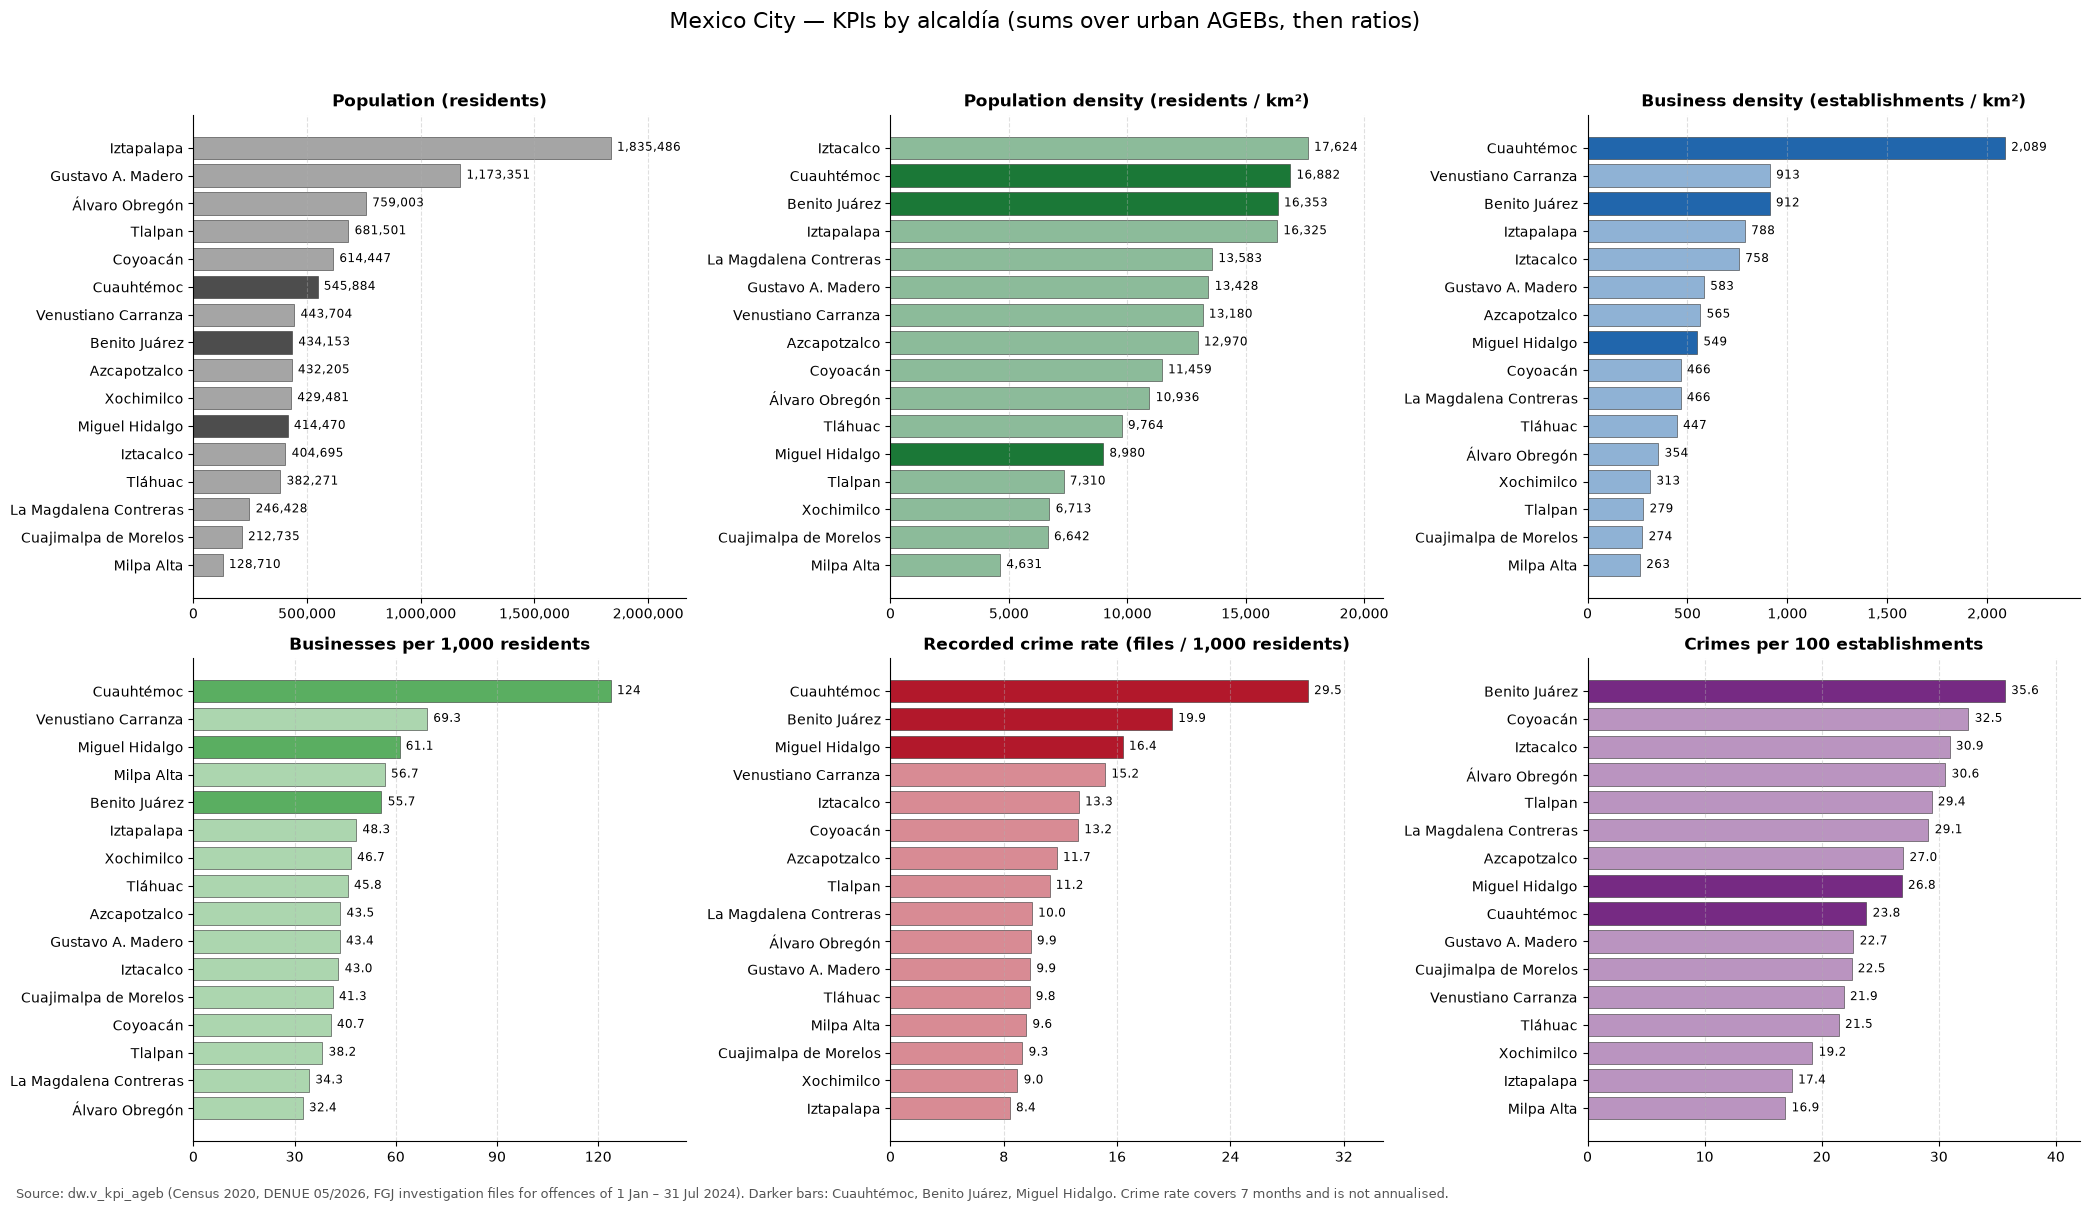

Saved alcaldía comparison figure to outputs\figures\35_alcaldia_comparison.png


In [6]:
metrics = [
    ('pop_total', 'Population (residents)', '#4d4d4d'),
    ('pop_density_km2', 'Population density (residents / km²)', '#1b7837'),
    ('business_density_km2', 'Business density (establishments / km²)', '#2166ac'),
    ('businesses_per_1k', 'Businesses per 1,000 residents', '#5aae61'),
    ('crime_rate_per_1k', 'Recorded crime rate (files / 1,000 residents)', '#b2182b'),
    ('crimes_per_100_businesses', 'Crimes per 100 establishments', '#762a83'),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for ax, (metric, label, color) in zip(axes.flatten(), metrics):
    ordered = alcaldia_df[metric].sort_values()
    colors = [color if name in CENTRE else color + '80' for name in ordered.index]
    bars = ax.barh(ordered.index, ordered.values, color=colors, edgecolor='#333', linewidth=0.4)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    top = ordered.max()
    for bar, value in zip(bars, ordered.values):
        ax.text(value + top * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{value:,.0f}" if value >= 100 else f"{value:,.1f}", va='center', fontsize=8.5)
    ax.set_xlim(0, top * 1.18)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

fig.suptitle("Mexico City — KPIs by alcaldía (sums over urban AGEBs, then ratios)", fontsize=16, y=0.995)
fig.text(0.01, 0.005, "Source: dw.v_kpi_ageb (Census 2020, DENUE 05/2026, FGJ investigation files for offences of 1 Jan – 31 Jul 2024). "
         "Darker bars: Cuauhtémoc, Benito Juárez, Miguel Hidalgo. Crime rate covers 7 months and is not annualised.",
         fontsize=9, color='#555')
plt.tight_layout(rect=(0, 0.02, 1, 0.97))

fig_path = OUTPUT_FIGURES / "35_alcaldia_comparison.png"
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved alcaldía comparison figure to {fig_path.relative_to(ROOT)}")

## 5. Interpretation

- **The centre has more establishments and more recorded crime than its resident population would suggest.** Cuauhtémoc, Benito Juárez and Miguel Hidalgo have 15.3 % of the urban population but 25.4 % of establishments and 28.1 % of recorded investigation files. Their crime rate (22.6 files per 1,000 residents) is more than twice that of the other 13 alcaldías (10.4), and they rank 1–3 on that KPI. Cuauhtémoc also leads on business density (2,089 establishments per km², more than twice Venustiano Carranza's 913 in second place) and on businesses per 1,000 residents (124).
- **Measured against business activity, the gap almost disappears.** Crimes per 100 establishments are 26.9 in the centre and 23.5 in the rest of the city. Cuauhtémoc ranks only 9th (23.8); Benito Juárez (35.6), Coyoacán (32.5) and Iztacalco (30.9) rank highest. An alcaldía's position depends on the denominator: the centre stands out per resident but not per establishment.
- **Iztapalapa** has the largest population (1.84 million residents) and ranks 4th on both population and business density. It has the lowest recorded crime rate (8.4 per 1,000) and the second-lowest crimes per 100 establishments (17.4).
- **Retail trade is the largest single SCIAN sector in all 16 alcaldías.** Its share of establishments ranges from 29 % (Benito Juárez) to 56 % (Xochimilco). Counted together, private services outnumber retail in 7 alcaldías, most clearly in Benito Juárez (58 % vs 29 %) and Miguel Hidalgo (53 % vs 32 %). Retail is about half or more of all establishments in Xochimilco, Venustiano Carranza and Milpa Alta.
- **Cautions.** The crime rate divides by resident population, but the centre takes in a large daytime population of commuters and visitors, so its rate per resident overstates the risk any one person faces there. Counts are investigation files (reported crime) for offences from January to July 2024 and are not annualised. Census 2020 and DENUE 2026 describe other dates. These comparisons describe associations between areas and do not support causal claims (report section 6).
